In [9]:
#1
import geopandas as gpd
import os

folder = r"C:\Users\IIST\Desktop\varsha\MTech26"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".shp"):

            path = os.path.join(root, file)

            gdf = gpd.read_file(path)

            print("Shapefile:", file)
            print("Projection:", gdf.crs)
            print("-----------------------------")

Shapefile: meghalaya.shp
Projection: EPSG:3857
-----------------------------
Shapefile: NE_states.shp
Projection: EPSG:3857
-----------------------------


In [10]:
#2
import geopandas as gpd
import os

folder = r"C:\Users\IIST\Desktop\varsha\MTech26"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".shp"):

            path = os.path.join(root, file)
            gdf = gpd.read_file(path)

            attributes = gdf.drop(columns="geometry")

            null_count = attributes.isnull().sum()

            print("\nShapefile:", file)
            print("Number of features:", len(gdf))
            print("\nNull entries in each attribute:")

            for column in attributes.columns:
                print(column, ":", null_count[column])

            total_nulls = null_count.sum()

            print("\nTotal null entries:", total_nulls)

            if total_nulls == 0:
                print("Status: No missing attributes")
            else:
                print("Status: Missing attributes found")

            print("-" * 50)



Shapefile: meghalaya.shp
Number of features: 1

Null entries in each attribute:
State_Name : 0

Total null entries: 0
Status: No missing attributes
--------------------------------------------------

Shapefile: NE_states.shp
Number of features: 7

Null entries in each attribute:
State_Name : 0

Total null entries: 0
Status: No missing attributes
--------------------------------------------------


Matplotlib is building the font cache; this may take a moment.



Shapefile: meghalaya.shp
Original CRS: EPSG:3857
New CRS: EPSG:4326
Saved: C:\Users\IIST\Desktop\varsha\MTech26\reprojected_EPSG4326\meghalaya_EPSG4326.shp

Shapefile: NE_states.shp
Original CRS: EPSG:3857
New CRS: EPSG:4326
Saved: C:\Users\IIST\Desktop\varsha\MTech26\reprojected_EPSG4326\NE_states_EPSG4326.shp


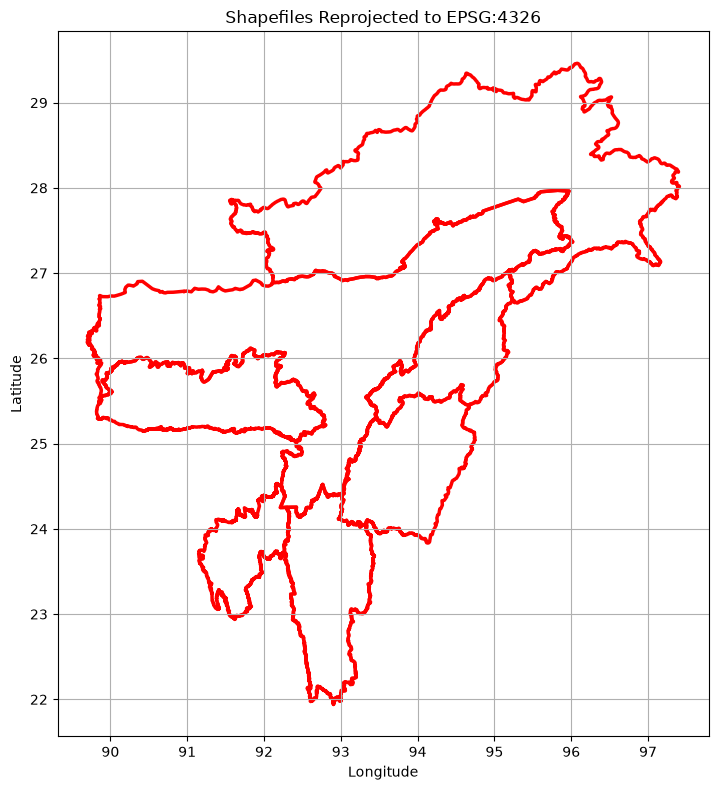

In [11]:
#3
import geopandas as gpd
import matplotlib.pyplot as plt
import os

input_folder = r"C:\Users\IIST\Desktop\varsha\MTech26"
output_folder = os.path.join(input_folder, "reprojected_EPSG4326")

os.makedirs(output_folder, exist_ok=True)

for root, dirs, files in os.walk(input_folder):

    dirs[:] = [d for d in dirs if d != "reprojected_EPSG4326"]

    for file in files:

        if file.lower().endswith(".shp"):

            input_path = os.path.join(root, file)

            gdf = gpd.read_file(input_path)

            print("\nShapefile:", file)
            print("Original CRS:", gdf.crs)

            gdf_4326 = gdf.to_crs(epsg=4326)

            print("New CRS:", gdf_4326.crs)

            output_name = os.path.splitext(file)[0] + "_EPSG4326.shp"
            output_path = os.path.join(output_folder, output_name)

            gdf_4326.to_file(output_path)

            print("Saved:", output_path)

fig, ax = plt.subplots(figsize=(8, 8))

for file in os.listdir(output_folder):

    if file.lower().endswith(".shp"):

        path = os.path.join(output_folder, file)

        gdf = gpd.read_file(path)

        if "NE_states" in file:

            gdf.plot(
                ax=ax,
                facecolor="none",
                edgecolor="red",
                linewidth=2.5
            )

        else:

            gdf.plot(
                ax=ax,
                facecolor="none",
                edgecolor="black",
                linewidth=1
            )

ax.set_title("Shapefiles Reprojected to EPSG:4326")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.grid(True)
plt.tight_layout()
plt.show()

Original CRS: EPSG:3857
Number of features: 7

Features included:
['Assam', 'Arunachal Pradesh', 'Nagaland', 'Manipur', 'Mizoram', 'Tripura', 'Meghalaya']

North Eastern State Areas:
       State_Name     Area_km2
Arunachal Pradesh 82045.708373
            Assam 78437.556144
        Meghalaya 22418.106934
          Manipur 22309.642886
          Mizoram 21065.766738
         Nagaland 16586.223593
          Tripura 10444.246300


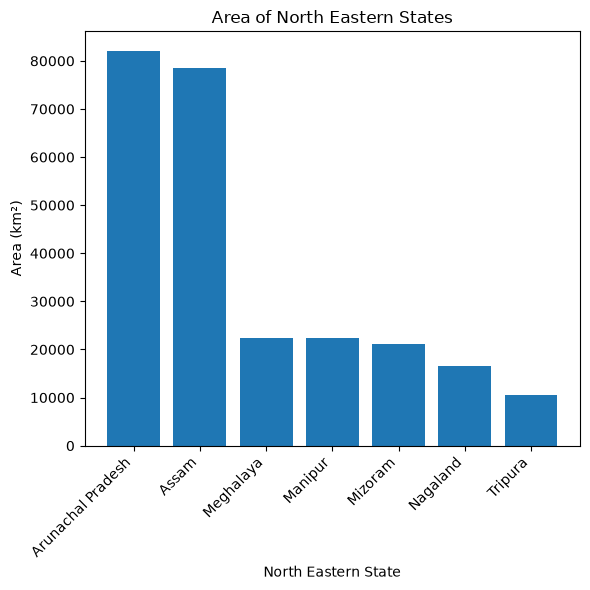

In [12]:
#4
import geopandas as gpd
import matplotlib.pyplot as plt
import os

input_path = r"C:\Users\IIST\Desktop\varsha\MTech26\NE_states\NE_states.shp"

gdf = gpd.read_file(input_path)

print("Original CRS:", gdf.crs)
print("Number of features:", len(gdf))

print("\nFeatures included:")
print(gdf["State_Name"].tolist())

gdf_area = gdf.to_crs(epsg=32646)

gdf["Area_km2"] = (
    gdf_area.geometry.area / 1_000_000
)

gdf_sorted = gdf.sort_values(
    by="Area_km2",
    ascending=False
)

print("\nNorth Eastern State Areas:")
print(
    gdf_sorted[["State_Name", "Area_km2"]].to_string(
        index=False
    )
)

plt.figure(figsize=(6, 6))

plt.bar(
    gdf_sorted["State_Name"],
    gdf_sorted["Area_km2"]
)

plt.xlabel("North Eastern State")
plt.ylabel("Area (km²)")
plt.title("Area of North Eastern States")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

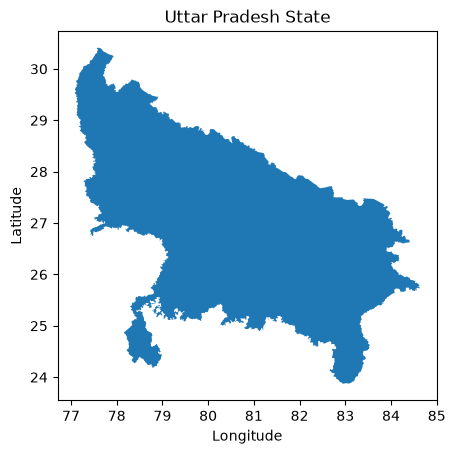

In [5]:
#5
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file(r"C:\Users\IIST\Desktop\varsha\MTech26\gadm41_IND_shp\gadm41_IND_1.shp")

Uttar_Pradesh = gdf[gdf["NAME_1"] == "Uttar Pradesh"]

Uttar_Pradesh.plot()

plt.title("Uttar Pradesh State")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Goa CRS: EPSG:4326
Saved to: C:\Users\IIST\Desktop\varsha\MTech26\Goa_EPSG4326.shp


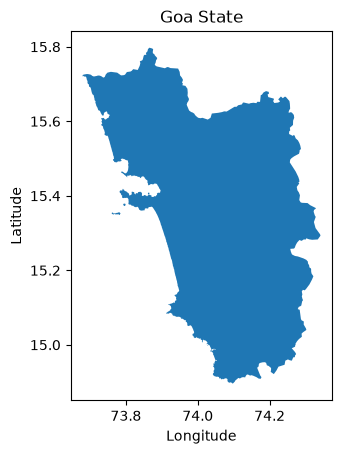

In [6]:
#6
import geopandas as gpd

input_path = r"C:\Users\IIST\Desktop\varsha\MTech26\gadm41_IND_shp\gadm41_IND_1.shp"

gdf = gpd.read_file(input_path)

Goa = gdf[gdf["NAME_1"] == "Goa"].copy()

Goa_4326 = Goa.to_crs(epsg=4326)

output_path = r"C:\Users\IIST\Desktop\varsha\MTech26\Goa_EPSG4326.shp"

Goa_4326.to_file(output_path)

print("Goa CRS:", Goa_4326.crs)
print("Saved to:", output_path)

Goa.plot()

plt.title("Goa State")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

                  NAME_2     Area_km2
611      Lakhimpur Kheri  7695.692949
636            Sonbhadra  6791.015864
600               Hardoi  6006.482834
635              Sitapur  5775.933522
567            Allahabad  5145.163245
..                   ...          ...
629     Sant Kabir Nagar  1327.112082
632               Shamli  1321.527407
599                Hapur  1104.798076
630  Sant Ravi Das Nagar  1008.896767
594            Ghaziabad   874.234703

[75 rows x 2 columns]


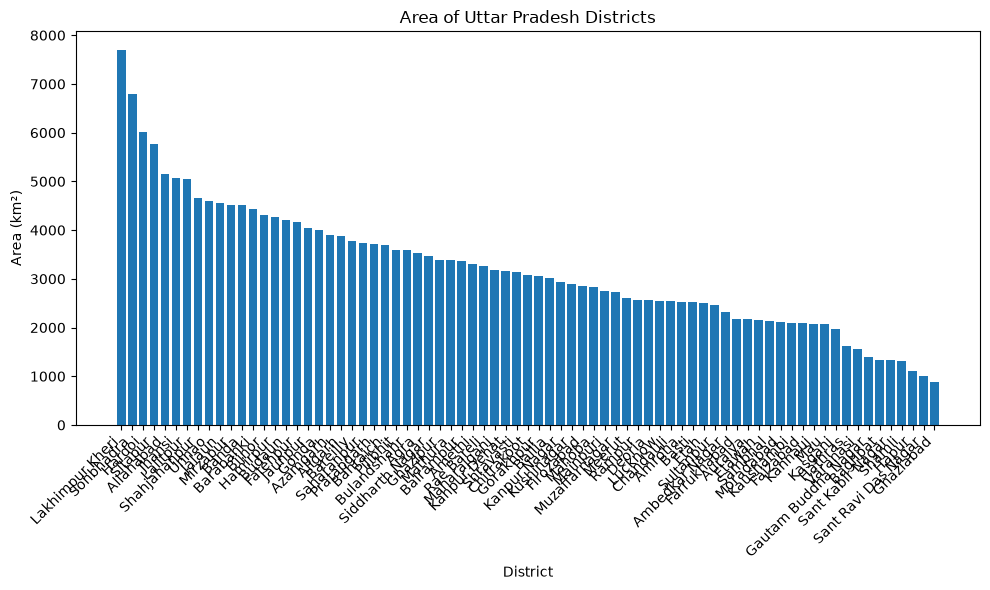

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

input_path = r"C:\Users\IIST\Desktop\varsha\MTech26\gadm41_IND_shp\gadm41_IND_2.shp"

gdf = gpd.read_file(input_path)

# Select Uttar Pradesh districts
Uttar_Pradesh = gdf[gdf["NAME_1"] == "Uttar Pradesh"].copy()

# Reproject to UTM Zone 44N for area calculation
Uttar_Pradesh_area = Uttar_Pradesh.to_crs(epsg=32644)

# Calculate area in km²
Uttar_Pradesh["Area_km2"] = Uttar_Pradesh_area.geometry.area / 1_000_000

# Sort districts by area
Uttar_Pradesh = Uttar_Pradesh.sort_values(
    by="Area_km2",
    ascending=False
)

# Print district areas
print(Uttar_Pradesh[["NAME_2", "Area_km2"]])

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    Uttar_Pradesh["NAME_2"],
    Uttar_Pradesh["Area_km2"]
)

plt.xlabel("District")
plt.ylabel("Area (km²)")
plt.title("Area of Uttar Pradesh Districts")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()
